Esta notebook utiliza el dataset **Weather Prediction Dataset**

Huber, F., van Kuppevelt, D., Steinbach, P., Sauze, C., Liu, Y., & Weel, B. (2022). Weather prediction dataset (Version v5) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.7525955

In [ ]:
# Importo librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Libreria que sirve para hacer el grid del plot con fechas más personalizable
import seaborn as sns

## Importación del nuevo dataset

In [ ]:
url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/weather_prediction_dataset.csv"

datos = pd.read_csv(url) # Se usa read_csv porque ese es el tipo de archivo de este dataset

In [ ]:
datos.head()


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


El dataset incluye información sobre 18 ciudades europeas

![Mapa del dataset](https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/Notebooks/weather_prediction_dataset_map.jpg)

Para obtener los datos de un país podemos filtrar los valores del dataset asi:

In [ ]:
ciudad = "BASEL" # Nombre de la ciudad de la que queremos obtener los datos

columnas_ciudad = [col for col in datos.columns if col.startswith(ciudad + "_")] # Con datos.columns se obtienen los nombres de todas las columnas
                                                                                 # Luego se buscan todos los nombres de columna que empiezan con
                                                                                 # el nombre de la ciudad elegida

datos_basel = datos[["DATE"] + ["MONTH"] + columnas_ciudad].copy() # Creo un nuevo dataframe con las columnas de la ciudad y las columnas de fecha y mes

datos_basel.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6


In [ ]:
datos_basel.columns = datos_basel.columns.str.replace("BASEL_", "", regex=False) # Quitamos el nombre de la ciudad del nombre de las columnas

datos_basel.head()

,DATE,MONTH,cloud_cover,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6


Las fechas no están en formato fecha, hay que convertirlas

In [ ]:
datos_basel['DATE'].dtype

dtype('int64')

In [ ]:
datos_basel["DATE"] = pd.to_datetime(datos_basel["DATE"], format="%Y%m%d")

datos_basel['DATE'].head()

,DATE
0,2000-01-01
1,2000-01-02
2,2000-01-03
3,2000-01-04
4,2000-01-05


Chequeamos que no haya datos vacios en ninguna columna

In [ ]:
datos_basel.isna().sum()

,0
DATE,0
MONTH,0
cloud_cover,0
humidity,0
pressure,0
global_radiation,0
precipitation,0
sunshine,0
temp_mean,0
temp_min,0


## Correlación Lineal entre variables

In [ ]:
variables = datos_basel.columns.drop(["DATE", "MONTH"]) # Los nombres de las columnas son mis variables (sin DATE y MONTH)
corr_lineal = datos_basel[variables].corr()


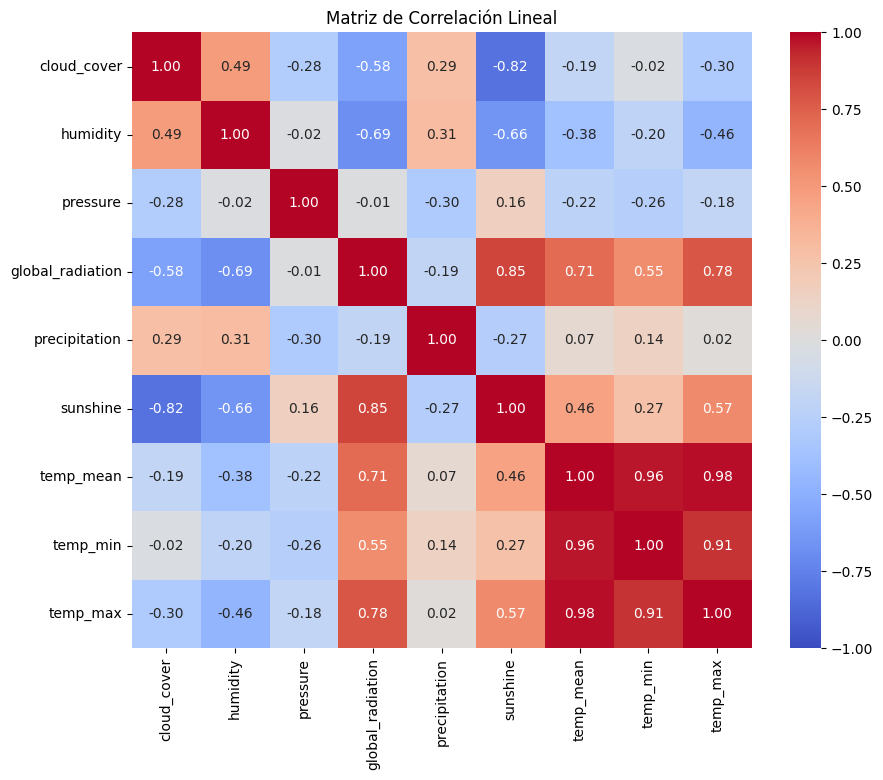

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
              corr_lineal,       # Matriz a graficar
              annot = True,      # Escribe el valor sobre cada cuadrado
              cmap = "coolwarm", # Escala de colores a usar
              vmin = -1,         # Valor Mínimo
              vmax = 1,          # Valor Máximo
              fmt = ".2f"        # Número de Decimales
          )

plt.title("Matriz de Correlación Lineal");


## Funcion general para graficar

In [ ]:
# Funcion general para graficar

def plot_y_pred(x, y, pred, modelo):

  plt.figure(figsize = (8, 5))
  plt.scatter(x, y, alpha = 0.3)
  plt.plot(x, pred, 'r', linewidth = 2)
  plt.xlabel("Humedad")
  plt.ylabel("Precipitación")
  plt.title( modelo + ": Humedad vs Precipitación")
  plt.show();

## Regresión Lineal

In [ ]:
# Variable independiente y variable objetivo
x = datos_basel["humidity"].to_numpy()
y = datos_basel["precipitation"].to_numpy()

# Matriz de diseño
X = np.column_stack((np.ones(len(x)), x))

X

array([[1.  , 0.89],
       [1.  , 0.87],
       [1.  , 0.81],
       ...,
       [1.  , 0.92],
       [1.  , 0.93],
       [1.  , 0.93]])

In [ ]:
# Ecuación de mínimos cuadrados
beta = np.linalg.inv(X.T @ X) @ X.T @ y

intercepto = beta[0]
pendiente = beta[1]

print("Intercepto:", intercepto)
print("Pendiente:", pendiente)

Intercepto: -0.9060787274242593
Pendiente: 1.5312278871117666


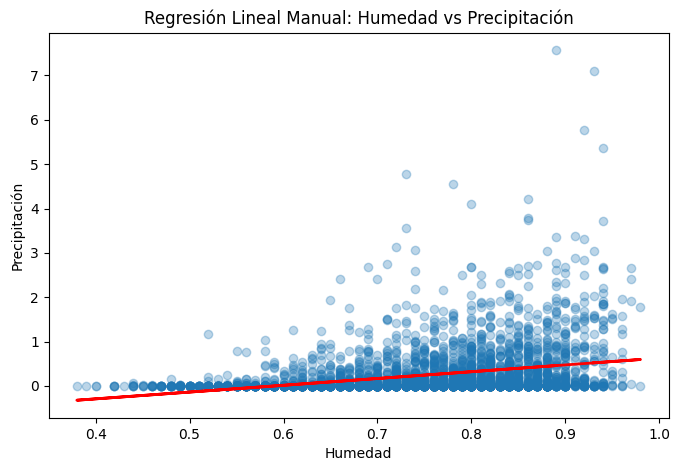

In [ ]:
# Calculamos el valor predicho para cada x
y_pred = X @ beta

plot_y_pred(x, y, y_pred, "Regresión Lineal Manual")

Para hacer el calculo de R² y medir que tan bien el modelo se ajusta a los datos:

In [ ]:
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - ss_res / ss_tot

print("R²:", r2)

R²: 0.09472263184553065


Podemos usar la librería **SKLEARN**

In [ ]:
from sklearn.linear_model import LinearRegression

X = datos_basel[["humidity"]]
y = datos_basel["precipitation"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_[0])
print("R²:", modelo.score(X, y))

Intercepto: -0.9060787274242847
Coeficiente: 1.531227887111803
R²: 0.09472263184553054


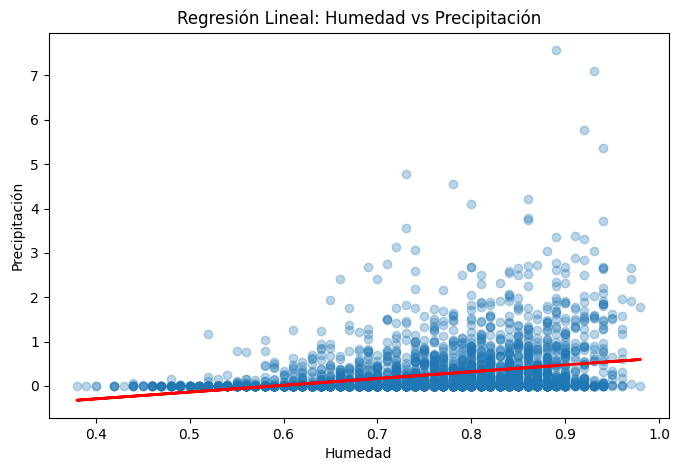

In [ ]:
# Calculamos el valor predicho para cada x
y_pred_lineal = modelo.predict(X)

plot_y_pred(X, y, y_pred_lineal, "Regresión Lineal")

## Regresión Lineal con Transformación de la Variable Objetivo

In [ ]:
X = datos_basel[["humidity"]]

# Transformacion de los datos de precipitacion
y_log = np.log1p(datos_basel["precipitation"])

modelo_log = LinearRegression()
modelo_log.fit(X, y_log)

print("Intercepto:", modelo_log.intercept_)
print("Coeficiente:", modelo_log.coef_[0])
print("R²:", modelo_log.score(X, y_log))

Intercepto: -0.5347871620455643
Coeficiente: 0.9294649047489101
R²: 0.12053039521366848


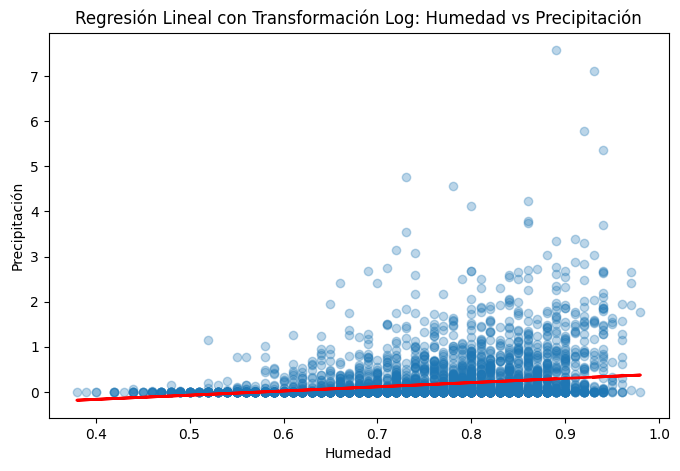

In [ ]:
# Calculamos el valor predicho para cada x
y_pred_log = modelo_log.predict(X)

plot_y_pred(X, y, y_pred_log, "Regresión Lineal con Transformación Log")

## Regresión Lineal con Transformación de una Variable

In [146]:
X = datos_basel[["humidity"]].copy()
y = datos_basel["precipitation"]

# Transformación de los datos de humedad
X["humidity_pow"] = np.power(X["humidity"], 2)

X.head()

,humidity,humidity_pow
0,0.89,0.7921
1,0.87,0.7569
2,0.81,0.6561
3,0.79,0.6241
4,0.90,0.8100


In [ ]:
# Usamos la variable transformada
X_pow = X[["humidity_log"]]

modelo_pow = LinearRegression()
modelo_pow.fit(X_pow, y)

print("Intercepto:", modelo_pow.intercept_)
print("Coeficiente:", modelo_pow.coef_[0])
print("R²:", modelo_pow.score(X_pow, y))

Intercepto: -0.38642113308769627
Coeficiente: 1.0961039044017549
R²: 0.10253963669849209


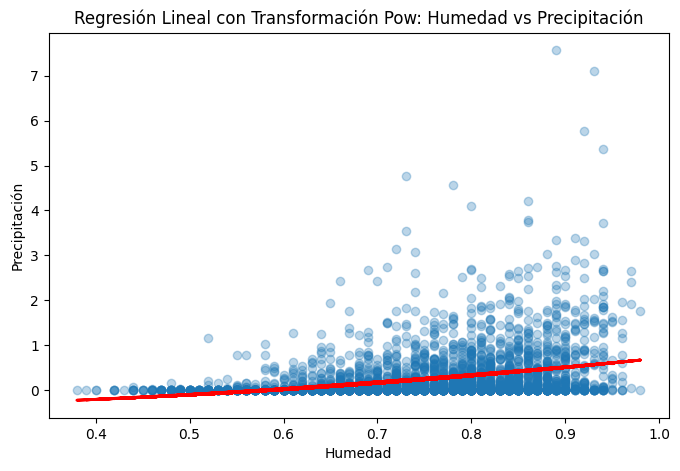

In [ ]:
# Calculamos el valor predicho para cada x
y_pred_pow = modelo_pow.predict(X_pow)

plot_y_pred(X['humidity'], y, y_pred_pow, "Regresión Lineal con Transformación Pow")


## Regresión Lineal Polinómica

In [144]:
from sklearn.preprocessing import PolynomialFeatures

X = datos_basel[["humidity"]]
y = datos_basel["precipitation"]

poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X)

X_poly

array([[1.    , 0.89  , 0.7921],
       [1.    , 0.87  , 0.7569],
       [1.    , 0.81  , 0.6561],
       ...,
       [1.    , 0.92  , 0.8464],
       [1.    , 0.93  , 0.8649],
       [1.    , 0.93  , 0.8649]])

In [145]:
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y)

print("R²:", modelo_poly.score(X_poly, y))
print("Coeficientes:", modelo_poly.coef_)

R²: 0.11725838790973098
Coeficientes: [ 0.         -6.59501756  5.61447854]


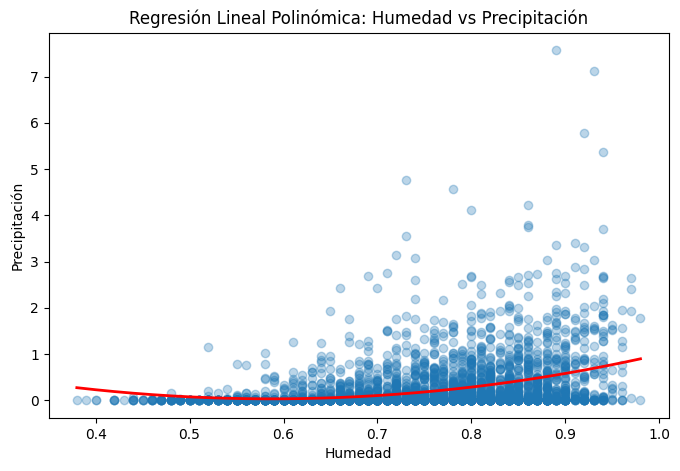

In [ ]:
# Creamos una tabla con valores ordenados de humedad para dibujar una curva suave
X_plot = np.linspace(
                      datos_basel["humidity"].min(),
                      datos_basel["humidity"].max(),
                      300
                      ).reshape(-1, 1)

X_plot = pd.DataFrame(X_plot, columns = ["humidity"])

# Transformamos esos valores igual que durante el entrenamiento
X_plot_poly = poly.transform(X_plot)

# Predicciones
y_plot = modelo_poly.predict(X_plot_poly)

# Gráfico
plt.figure(figsize=(8, 5))

plt.scatter(datos_basel["humidity"], datos_basel["precipitation"], alpha=0.3)
plt.plot(X_plot, y_plot, color = 'r', linewidth = 2)

plt.xlabel("Humedad")
plt.ylabel("Precipitación")
plt.title("Regresión Lineal Polinómica: Humedad vs Precipitación")
plt.show();

## Regresión Lineal Múltiple

In [ ]:
variables_X = [
    "humidity",
    "pressure",
    "cloud_cover",
    "sunshine"
]

X = datos_basel[variables_X]
y = datos_basel["precipitation"]

modelo_multiple = LinearRegression()
modelo_multiple.fit(X, y)

print("Intercepto:", modelo_multiple.intercept_)
print("Coeficientes:")

for variable, coef in zip(variables_X, modelo_multiple.coef_):
    print(f"{variable}: {coef}")

print("R²:", modelo_multiple.score(X, y))

Intercepto: 17.722084132545692
Coeficientes:
humidity: 1.3676504820397486
pressure: -18.34308578257706
cloud_cover: 0.02581184342752607
sunshine: 0.005331140063233875
R²: 0.18775188770115525


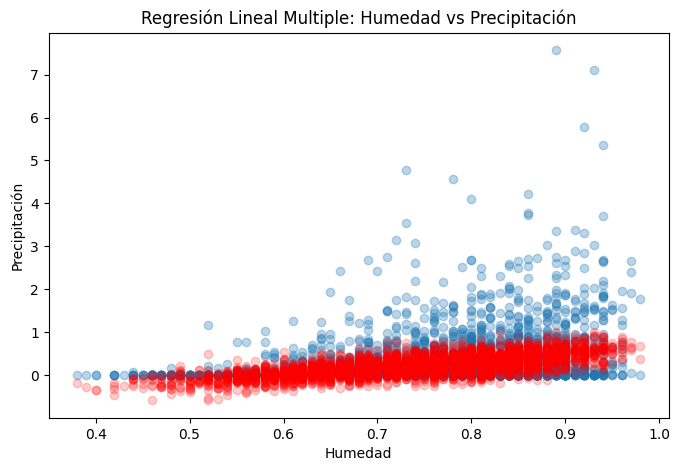

In [ ]:
# Calculamos el valor predicho para cada x
y_pred_multiple = modelo_multiple.predict(X)

plt.figure(figsize = (8, 5))
plt.scatter(X['humidity'], y, alpha = 0.3)
plt.scatter(X['humidity'], y_pred_multiple, alpha = 0.2, color = 'r')
plt.xlabel("Humedad")
plt.ylabel("Precipitación")
plt.title("Regresión Lineal Multiple: Humedad vs Precipitación")
plt.show();